<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_06_Case_study_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CASE STUDY 03

##Computer Vision
##Classifying Fruits and Vegetables Using Image Classification

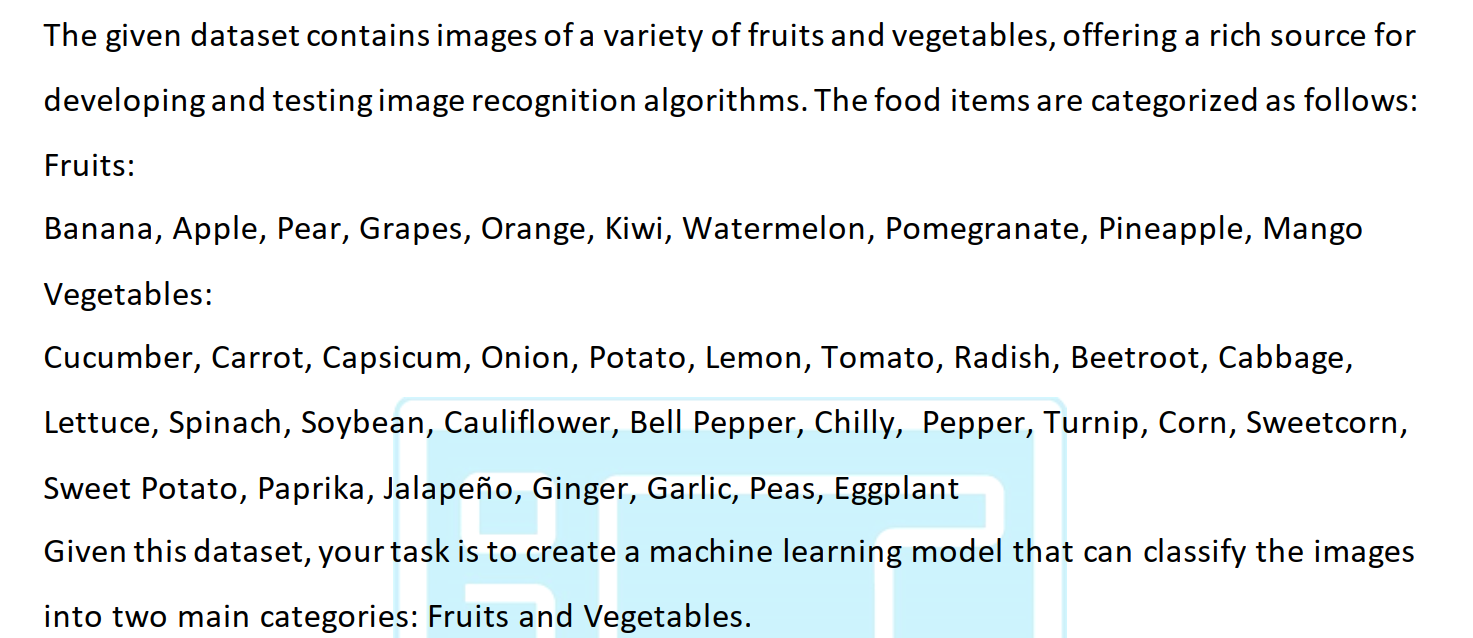

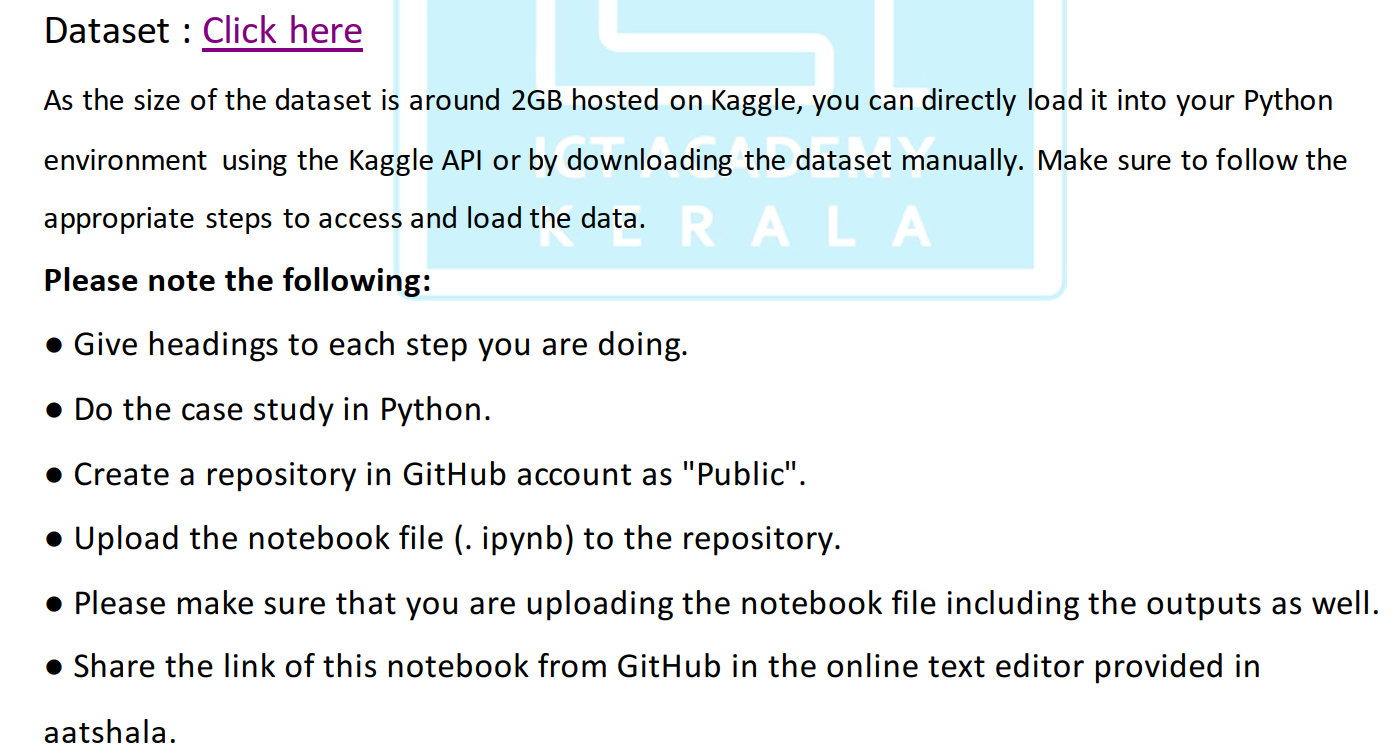

Dataset:https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition

#Manual Upload and unzip

In [4]:
import zipfile
import os

zip_ref = zipfile.ZipFile('/content/archive.zip', 'r')
zip_ref.extractall('/content/fruits_vegetables')
zip_ref.close()

#Import Required Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Prepare the Data

In [7]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    'fruits_vegetables',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    'fruits_vegetables',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 3061 images belonging to 3 classes.
Found 764 images belonging to 3 classes.


#Build the CNN Model

In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Train the Model

In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.7783 - loss: 12.1010 - val_accuracy: 0.8154 - val_loss: 0.0354
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.8113 - loss: 0.6824 - val_accuracy: 0.8154 - val_loss: 0.0155
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8127 - loss: 0.5406 - val_accuracy: 0.8154 - val_loss: 0.0123
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8160 - loss: 0.0722 - val_accuracy: 0.8154 - val_loss: 0.0224
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8063 - loss: 0.0153 - val_accuracy: 0.8154 - val_loss: 0.0174
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8158 - loss: 0.0530 - val_accuracy: 0.8154 - val_loss: 0.0112
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8029 - loss: 0.1498 - val_accuracy: 0.8154 - val_loss: 0.0164
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8246 - loss: 0.1854 - val_accuracy: 0.8154 - val_loss: 0

#Evaluate and Visualize

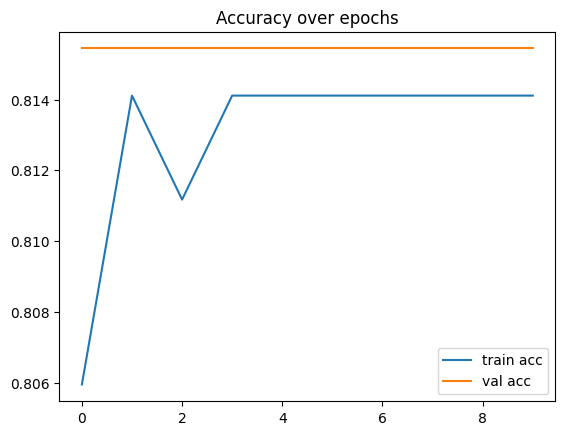

In [10]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()